# Phase 3: 歯科ドメイン適応学習 (Stage 3a + Stage 3b)

**目的**: PatchAlign3D を歯科点群データ (normPLYs + candidates.json) でファインチューニングし、
解剖学的パッチ‑テキスト対応を学習させる。

**参照**: `design_docs/PatchAligned3D_phases/phase3_training_plan.md`

---
**チェックリスト**
```
[ ] Google Drive マウント
[ ] GPU / CUDA 確認
[ ] 必要パッケージのインストール確認
[ ] pointnet2_ops / KNN_CUDA ビルド成功
[ ] open_clip import 成功 (ViT-bigG-14 ロード)
[ ] PatchAlign3D パッケージ install 成功
[ ] HF チェックポイント (patchalign3d.pt) ダウンロード完了
[ ] データセット検証: 20 PLY + candidates.json 整合性確認
[ ] Stage 3a 学習完了 (30 epochs)
[ ] Stage 3b 学習完了 (50 epochs)
[ ] stage3b_best.pt 保存確認
```

## Step 0 — Google Drive マウント & パス設定

In [43]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [44]:
import sys, os

# ===== パス設定 =====
DRIVE_ROOT   = '/content/drive/MyDrive'
REPO_ROOT    = f'{DRIVE_ROOT}/2026研究/ULIP_PointLLM'
PA3D_REF     = f'{REPO_ROOT}/_reference_repos/PatchAlign3D'
PHASE3_DIR   = f'{REPO_ROOT}/DentalPatchAligned3D/Phase3_Training'
CKPT_DIR     = f'{REPO_ROOT}/checkpoints/patchalign3d'

# データパス
PLY_DIR      = f'{DRIVE_ROOT}/2026研究/Dataset/6167726/STLs/STLs/normPLYs'
JSON_PATH    = f'{REPO_ROOT}/data/DentalPatchData/dental_vocab/candidates.json'

# 出力ディレクトリ
OUT_3A       = f'{PHASE3_DIR}/outputs/stage3a'
OUT_3B       = f'{PHASE3_DIR}/outputs/stage3b'

for d in [CKPT_DIR, OUT_3A, OUT_3B]:
    os.makedirs(d, exist_ok=True)

print(f'REPO_ROOT  : {REPO_ROOT}')
print(f'PHASE3_DIR : {PHASE3_DIR}')
print(f'PLY_DIR    : {PLY_DIR}')
print(f'JSON_PATH  : {JSON_PATH}')
print(f'CKPT_DIR   : {CKPT_DIR}')

REPO_ROOT  : /content/drive/MyDrive/2026研究/ULIP_PointLLM
PHASE3_DIR : /content/drive/MyDrive/2026研究/ULIP_PointLLM/DentalPatchAligned3D/Phase3_Training
PLY_DIR    : /content/drive/MyDrive/2026研究/Dataset/6167726/STLs/STLs/normPLYs
JSON_PATH  : /content/drive/MyDrive/2026研究/ULIP_PointLLM/data/DentalPatchData/dental_vocab/candidates.json
CKPT_DIR   : /content/drive/MyDrive/2026研究/ULIP_PointLLM/checkpoints/patchalign3d


## Step 1 — GPU / CUDA 確認

In [45]:
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device      : {device}')
print(f'torch       : {torch.__version__}')

if device == 'cuda':
    print(f'GPU         : {torch.cuda.get_device_name(0)}')
    print(f'VRAM        : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    print(f'CUDA        : {torch.version.cuda}')
else:
    print('WARNING: GPU が利用できません。ランタイムを「GPU」に変更してください。')

device      : cuda
torch       : 2.10.0+cu128
GPU         : NVIDIA A100-SXM4-40GB
VRAM        : 42.4 GB
CUDA        : 12.8


## Step 2 — パッケージインストール

> **Colab 注意事項**
> - `torch`, `torchvision`, `numpy`, `Pillow` は Colab に既インストール済みのため **再インストール不要**
> - `open3d==0.17.0` は Python 3.12 に対応していないため **バージョン指定なし** でインストール
> - `wandb` は学習時のみ必要なため、使わない場合は **スキップ可**

In [46]:
# 既インストール済みパッケージの確認
import importlib

PREINSTALLED = ['torch', 'torchvision', 'numpy', 'PIL', 'tqdm']
NEED_INSTALL  = ['open_clip', 'timm', 'easydict', 'termcolor', 'open3d', 'ninja',
                 'huggingface_hub', 'plyfile', 'yaml']

print('=== 既インストール確認 ===')
for pkg in PREINSTALLED:
    try:
        mod = importlib.import_module(pkg)
        ver = getattr(mod, '__version__', 'unknown')
        print(f'  [OK] {pkg} {ver}')
    except ImportError:
        print(f'  [NG] {pkg} — 要インストール')

print('\n=== 追加インストール要否 ===')
for pkg in NEED_INSTALL:
    try:
        mod = importlib.import_module(pkg)
        ver = getattr(mod, '__version__', 'unknown')
        print(f'  [OK] {pkg} {ver}')
    except ImportError:
        print(f'  [要] {pkg}')

=== 既インストール確認 ===
  [OK] torch 2.10.0+cu128
  [OK] torchvision 0.25.0+cu128
  [OK] numpy 2.0.2
  [OK] PIL 11.3.0
  [OK] tqdm 4.67.3

=== 追加インストール要否 ===
  [OK] open_clip 3.3.0
  [OK] timm 1.0.26
  [OK] easydict unknown
  [OK] termcolor unknown
  [OK] open3d 0.19.0
  [OK] ninja 1.13.0
  [OK] huggingface_hub 1.10.1
  [OK] plyfile unknown
  [OK] yaml 6.0.3


In [47]:
# ===== 追加パッケージのインストール =====
!pip install open_clip_torch>=2.24.0 timm easydict termcolor ninja open3d plyfile pyyaml -q

import open_clip, timm, easydict, termcolor, open3d, plyfile
print(f'open_clip : {open_clip.__version__}')
print(f'timm      : {timm.__version__}')
print(f'open3d    : {open3d.__version__}')
print(f'plyfile   : {getattr(plyfile, "__version__", "installed (no __version__)")}')
print('追加パッケージ OK')

open_clip : 3.3.0
timm      : 1.0.26
open3d    : 0.19.0
plyfile   : installed (no __version__)
追加パッケージ OK


## Step 3 — pointnet2_ops / KNN_CUDA のインストール

> `ninja` が必要（Step 2 でインストール済み）  
> Colab の CUDA バージョンに自動対応

In [48]:
import os, torch, shutil

# 1. 環境リセット
%cd /content
if os.path.exists('/tmp/Pointnet2_PyTorch'):
    shutil.rmtree('/tmp/Pointnet2_PyTorch')

!git clone --quiet --depth 1 https://github.com/erikwijmans/Pointnet2_PyTorch.git /tmp/Pointnet2_PyTorch

# 2. ソースコードのパッチ (AT_CHECK 置換 & THC 除去)
# CUDA 12 系でコンパイルエラーを回避するため必須
!find /tmp/Pointnet2_PyTorch/pointnet2_ops_lib/pointnet2_ops/_ext-src/src -type f -exec sed -i 's/AT_CHECK/TORCH_CHECK/g' {} +
!find /tmp/Pointnet2_PyTorch/pointnet2_ops_lib/pointnet2_ops/_ext-src/src -type f -exec sed -i '/#include <THC\/THC.h>/d' {} +

# 3. setup.py の CUDA アーキテクチャを現在の GPU に合わせる
major, minor = torch.cuda.get_device_capability()
new_arch = f'{major}.{minor}'
SETUP_PY = '/tmp/Pointnet2_PyTorch/pointnet2_ops_lib/setup.py'
!sed -i 's/os.environ\["TORCH_CUDA_ARCH_LIST"\] = .*/os.environ["TORCH_CUDA_ARCH_LIST"] = "{new_arch}"/g' {SETUP_PY}
print(f'setup.py patched: TORCH_CUDA_ARCH_LIST = {new_arch}')

# 4. インストール
%cd /tmp/Pointnet2_PyTorch/pointnet2_ops_lib
!pip -v install .

# 5. 確認
%cd /content
try:
    from pointnet2_ops import pointnet2_utils
    print('pointnet2_ops: インストール成功')
except Exception as e:
    print(f'pointnet2_ops: 失敗 → {e}')

/content
setup.py patched: TORCH_CUDA_ARCH_LIST = 8.0
/tmp/Pointnet2_PyTorch/pointnet2_ops_lib
Using pip 24.1.2 from /usr/local/lib/python3.12/dist-packages/pip (python 3.12)
Processing /tmp/Pointnet2_PyTorch/pointnet2_ops_lib
  Running command python setup.py egg_info
  running egg_info
  creating /tmp/pip-pip-egg-info-j3a7m_q6/pointnet2_ops.egg-info
  writing /tmp/pip-pip-egg-info-j3a7m_q6/pointnet2_ops.egg-info/PKG-INFO
  writing dependency_links to /tmp/pip-pip-egg-info-j3a7m_q6/pointnet2_ops.egg-info/dependency_links.txt
  writing requirements to /tmp/pip-pip-egg-info-j3a7m_q6/pointnet2_ops.egg-info/requires.txt
  writing top-level names to /tmp/pip-pip-egg-info-j3a7m_q6/pointnet2_ops.egg-info/top_level.txt
  writing manifest file '/tmp/pip-pip-egg-info-j3a7m_q6/pointnet2_ops.egg-info/SOURCES.txt'
  reading manifest file '/tmp/pip-pip-egg-info-j3a7m_q6/pointnet2_ops.egg-info/SOURCES.txt'
  reading manifest template 'MANIFEST.in'
  writing manifest file '/tmp/pip-pip-egg-info-j3a7m

In [49]:
# KNN_CUDA (kNN 近傍探索)
try:
    from knn_cuda import KNN
    print('knn_cuda: すでにインストール済み')
except ImportError:
    print('KNN_CUDA をインストール中...')
    !pip install --upgrade https://github.com/unlimblue/KNN_CUDA/releases/download/0.2/KNN_CUDA-0.2-py3-none-any.whl -q
    from knn_cuda import KNN
    print('knn_cuda: インストール完了')

knn_cuda: すでにインストール済み


In [50]:
# ビルド確認
from pointnet2_ops import pointnet2_utils
from knn_cuda import KNN
print('pointnet2_ops + KNN_CUDA: OK')

pointnet2_ops + KNN_CUDA: OK


## Step 4 — PatchAlign3D & Phase3 パスをロード

In [51]:
import sys, os, types

# PatchAlign3D 参照リポジトリ
PA3D_SRC = f'{PA3D_REF}/src'
if PA3D_SRC not in sys.path:
    sys.path.insert(0, PA3D_SRC)

# patchalign3d パッケージとして登録
if 'patchalign3d' not in sys.modules:
    mod = types.ModuleType('patchalign3d')
    mod.__path__ = [PA3D_SRC]
    sys.modules['patchalign3d'] = mod

# Phase3_Training ディレクトリ (datasets / models / losses をインポートするため)
if PHASE3_DIR not in sys.path:
    sys.path.insert(0, PHASE3_DIR)

# 確認
import models, datasets
print('PatchAlign3D + Phase3_Training: パス設定 OK')

PatchAlign3D + Phase3_Training: パス設定 OK


## Step 5 — データセット検証

PLY ファイルと `candidates.json` の整合性を確認する。  
期待: 20 PLY × 32 パッチ × 5 テキスト

In [52]:
import json
from pathlib import Path

# PLY ファイル一覧
ply_files = sorted(Path(PLY_DIR).glob('*.ply'))
print(f'PLY ファイル数: {len(ply_files)}')
for p in ply_files:
    print(f'  {p.name}')

print()

# candidates.json
with open(JSON_PATH, 'r', encoding='utf-8') as f:
    candidates = json.load(f)

print(f'candidates.json キー数 (患者数): {len(candidates)}')
for pat_id, patches in list(candidates.items())[:3]:
    print(f'  {pat_id}: {len(patches)} パッチ, texts[0] = "{patches[0]["texts"][0][:50]}..."')
print('  ...')

# 整合性チェック: PLY ↔ JSON キーの対応
ply_stems = {p.stem for p in ply_files}
json_keys = set(candidates.keys())
matched = ply_stems & json_keys
print(f'\n整合: PLY={len(ply_stems)}, JSON={len(json_keys)}, マッチ={len(matched)}')
if ply_stems - json_keys:
    print(f'  JSON にない PLY: {ply_stems - json_keys}')
if json_keys - ply_stems:
    print(f'  PLY にない JSON キー: {json_keys - ply_stems}')
assert len(matched) > 0, 'PLY と JSON のマッチが 0 件です！パスを確認してください。'
print('データセット整合性 OK')

PLY ファイル数: 20
  Pat 10na_norm.ply
  Pat 10nb_norm.ply
  Pat 1a_norm.ply
  Pat 1b_norm.ply
  Pat 2a_norm.ply
  Pat 2b_norm.ply
  Pat 3a_norm.ply
  Pat 3b_norm.ply
  Pat 4a_norm.ply
  Pat 4b_norm.ply
  Pat 5a_norm.ply
  Pat 5b_norm.ply
  Pat 6a_norm.ply
  Pat 6b_norm.ply
  Pat 7a_norm.ply
  Pat 7b_norm.ply
  Pat 8a_norm.ply
  Pat 8b_norm.ply
  Pat 9na_norm.ply
  Pat 9nb_norm.ply

candidates.json キー数 (患者数): 20
  Pat 10na_norm: 32 パッチ, texts[0] = "Right body of mandible along the rounded inferior ..."
  Pat 10nb_norm: 32 パッチ, texts[0] = "Left coronoid process, a pointed triangular projec..."
  Pat 1a_norm: 32 パッチ, texts[0] = "Midline mental protuberance forms a broad convex p..."
  ...

整合: PLY=20, JSON=20, マッチ=20
データセット整合性 OK


In [53]:
# DentalPatchDataset で実際にロードできるか確認
from phase3_datasets.dental_dataset import DentalPatchDataset

ds_check = DentalPatchDataset(
    ply_dir    = PLY_DIR,
    json_path  = JSON_PATH,
    npoints    = 2048,
    mode       = '3b',
    split      = 'train',
    val_ratio  = 0.2,
    seed       = 42,
)
print(f'Train 患者数: {len(ds_check)}')

sample = ds_check[0]
print(f'points       : {sample["points"].shape}  (期待: torch.Size([3, 2048]))')
print(f'point_labels : {sample["point_labels"].shape}')
print(f'label_masks  : {sample["label_masks"].shape}')
print(f'label_names  : {len(sample["label_names"])} テキスト (先頭: "{sample["label_names"][0][:50]}...")')
print(f'item_id      : {sample["item_id"]}')
print('\nデータセットロード OK')

Train 患者数: 16
points       : torch.Size([3, 2048])  (期待: torch.Size([3, 2048]))
point_labels : torch.Size([2048])
label_masks  : torch.Size([32, 2048])
label_names  : 32 テキスト (先頭: "Right body of mandible along the rounded inferior ...")
item_id      : Pat 10na_norm

データセットロード OK


## Step 6 — open_clip ロード確認 (ViT-bigG-14)

> 初回は約 10 GB のダウンロードが発生します。2 回目以降はキャッシュが利用されます。

In [54]:
import open_clip, torch

print('ViT-bigG-14 / laion2b_s39b_b160k をロード中... (初回は ~10GB ダウンロード)')
clip_model, _, _ = open_clip.create_model_and_transforms(
    'ViT-bigG-14', pretrained='laion2b_s39b_b160k'
)
clip_model = clip_model.to(device)
tokenizer = open_clip.get_tokenizer('ViT-bigG-14')

# テキスト特徴次元確認
dummy = tokenizer(['mandibular condyle'])
with torch.no_grad():
    feat = clip_model.encode_text(dummy.to(device))
print(f'テキスト特徴次元: {feat.shape[-1]} (期待値: 1280)')
assert feat.shape[-1] == 1280, f'次元不一致: {feat.shape[-1]}'

# メモリ節約のため CPU に移動 (学習中は text_cache が管理)
clip_model = clip_model.cpu()
print('open_clip ViT-bigG-14: OK')

ViT-bigG-14 / laion2b_s39b_b160k をロード中... (初回は ~10GB ダウンロード)
テキスト特徴次元: 1280 (期待値: 1280)
open_clip ViT-bigG-14: OK


## Step 7 — HuggingFace チェックポイントのダウンロード

> Stage 2 事前学習済みチェックポイント `patchalign3d.pt` をダウンロードします。  
> **注意**: 公開チェックポイントは `color=False` (入力 C=3, xyz のみ) で学習済み。

In [55]:
import os
from huggingface_hub import hf_hub_download
import torch

FILENAME  = 'patchalign3d.pt'
CKPT_PATH = os.path.join(CKPT_DIR, FILENAME)

if os.path.exists(CKPT_PATH):
    print(f'チェックポイント既存: {CKPT_PATH}')
else:
    print(f'チェックポイントをダウンロード中... ({FILENAME})')
    downloaded = hf_hub_download(
        repo_id  = 'patchalign3d/patchalign3d-encoder',
        filename = FILENAME,
    )
    import shutil
    shutil.copy(downloaded, CKPT_PATH)
    print(f'保存: {CKPT_PATH}')

# チェックポイントの形式確認
ckpt = torch.load(CKPT_PATH, map_location='cpu', weights_only=False)
keys = list(ckpt.keys()) if isinstance(ckpt, dict) else ['(tensor)']
print(f'チェックポイントキー: {keys[:8]}')
print('チェックポイント確認 OK')

チェックポイント既存: /content/drive/MyDrive/2026研究/ULIP_PointLLM/checkpoints/patchalign3d/patchalign3d.pt
チェックポイントキー: ['model', 'proj']
チェックポイント確認 OK


## Step 8 — Colab 用 YAML 設定ファイルの生成

ローカルの相対パスを Colab 絶対パスで上書きした設定ファイルを `/content/` 以下に書き出します。

In [56]:
import yaml, os

# ===== Stage 3a 設定 =====
cfg_3a = {
    'seed': 42,
    'output_dir': OUT_3A,
    'data': {
        'ply_dir':   PLY_DIR,
        'json_path': JSON_PATH,
        'npoints':   2048,
        'val_ratio': 0.2,
    },
    'clip': {
        'model':          'ViT-bigG-14',
        'pretrained':     'laion2b_s39b_b160k',
        'cache_capacity': 5000,
    },
    'model': {
        'trans_dim':       384,
        'depth':           12,
        'drop_path_rate':  0.1,
        'cls_dim':         50,
        'num_heads':       6,
        'group_size':      32,
        'num_group':       128,
        'encoder_dims':    256,
        'color':           False,
        'num_classes':     16,
        'clip_dim':        1280,
        'clip_tau':        0.07,
        'stage2_ckpt':     CKPT_PATH,
    },
    'loss': {
        'lambda_infonce': 1.0,
        'lambda_kd':      0.2,
    },
    'training': {
        'epochs':       500,
        'batch_size':   4,
        'lr':           3e-5,
        'lr_min':       1e-6,
        'weight_decay': 0.5,
        'num_workers':  2,
        'eval_every':   20,
        'save_every':   20,
    },
}

CFG_3A_PATH = '/content/stage3a_colab.yaml'
with open(CFG_3A_PATH, 'w', encoding='utf-8') as f:
    yaml.dump(cfg_3a, f, allow_unicode=True, sort_keys=False)
print(f'Stage 3a config: {CFG_3A_PATH}')

# ===== Stage 3b 設定 =====
STAGE3A_LAST = os.path.join(OUT_3A, 'stage3a_last.pt')

cfg_3b = {
    'seed': 42,
    'output_dir': OUT_3B,
    'data': {
        'ply_dir':      PLY_DIR,
        'json_path':    JSON_PATH,
        'npoints':      2048,
        'val_ratio':    0.1,
        'text_augment': True,
    },
    'clip': {
        'model':          'ViT-bigG-14',
        'pretrained':     'laion2b_s39b_b160k',
        'cache_capacity': 10000,
    },
    'model': {
        'trans_dim':       384,
        'depth':           12,
        'drop_path_rate':  0.1,
        'cls_dim':         50,
        'num_heads':       6,
        'group_size':      32,
        'num_group':       128,
        'encoder_dims':    256,
        'color':           False,
        'num_classes':     16,
        'clip_dim':        1280,
        'clip_tau':        0.07,
        'stage3a_ckpt':    STAGE3A_LAST,
        'stage2_ckpt':     CKPT_PATH,
    },
    'loss': {
        'lambda_bce':           1.0,
        'lambda_kd':            0.5,
        'lambda_ewc':           1000.0,
        'lambda_kd_text':       0.0,
        'ewc_fisher_batches':   50,
    },
    'training': {
        'epochs':        1000,
        'batch_size':    1024,
        'lr':            3e-5,
        'weight_decay':  0.5,
        'warmup_epochs': 5,
        'num_workers':   2,
        'eval_every':    20,
        'save_every':    100,
    },
}

CFG_3B_PATH = '/content/stage3b_colab.yaml'
with open(CFG_3B_PATH, 'w', encoding='utf-8') as f:
    yaml.dump(cfg_3b, f, allow_unicode=True, sort_keys=False)
print(f'Stage 3b config: {CFG_3B_PATH}')
print('\nColab 用 YAML 設定ファイル生成 OK')

Stage 3a config: /content/stage3a_colab.yaml
Stage 3b config: /content/stage3b_colab.yaml

Colab 用 YAML 設定ファイル生成 OK


## Step 9 — Stage 3a 学習 (領域パッチ InfoNCE、30 エポック)

```
点群 (2048点)
 ↓ forward_patches
patch_emb (B, 384, 128)  +  patch_idx (B, 128, 32)
 ↓ proj
patch_feat (B, 128, 1280)
 ↓ InfoNCE vs 9-octant テキスト
Loss = InfoNCE + λ_kd × MSE(student, teacher)
```

> **出力**: `outputs/stage3a/checkpoints/best.pt` + `stage3a_last.pt`

In [57]:
%cd {PHASE3_DIR}
!python train_stage3a.py --config {CFG_3A_PATH}

/content/drive/MyDrive/2026研究/ULIP_PointLLM/DentalPatchAligned3D/Phase3_Training
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
2026-04-16 16:45:56,862 INFO Config: {'seed': 42, 'output_dir': '/content/drive/MyDrive/2026研究/ULIP_PointLLM/DentalPatchAligned3D/Phase3_Training/outputs/stage3a', 'data': {'ply_dir': '/content/drive/MyDrive/2026研究/Dataset/6167726/STLs/STLs/normPLYs', 'json_path': '/content/drive/MyDrive/2026研究/ULIP_PointLLM/data/DentalPatchData/dental_vocab/candidates.json', 'npoints': 2048, 'val_ratio': 0.2}, 'clip': {'model': 'ViT-bigG-14', 'pretrained': 'laion2b_s39b_b160k', 'cache_capacity': 5000}, 'model': {'trans_dim': 384, 'depth': 12, 'drop_path_rate': 0.1, 'cls_dim': 50, 'num_heads': 6, 'group_size': 32, 'num_group': 128, 'encoder_dims': 256, 

In [58]:
# Stage 3a チェックポイント確認
import os, torch

stage3a_last = os.path.join(OUT_3A, 'stage3a_last.pt')
stage3a_best = os.path.join(OUT_3A, 'checkpoints', 'best.pt')

assert os.path.exists(stage3a_last), f'stage3a_last.pt が見つかりません: {stage3a_last}'
assert os.path.exists(stage3a_best), f'best.pt が見つかりません: {stage3a_best}'

ckpt = torch.load(stage3a_last, map_location='cpu', weights_only=False)
print(f'Stage 3a last ckpt epoch: {ckpt["epoch"]}')
print(f'  student keys (先頭3): {list(ckpt["student"].keys())[:3]} ...')

ckpt_best = torch.load(stage3a_best, map_location='cpu', weights_only=False)
val_loss = ckpt_best.get('val_metrics', {}).get('val_loss', float('nan'))
print(f'Stage 3a best val_loss: {val_loss:.4f}')
print('Stage 3a 完了 ✓')

Stage 3a last ckpt epoch: 500
  student keys (先頭3): ['cls_token', 'cls_pos', 'encoder.first_conv.0.weight'] ...
Stage 3a best val_loss: 0.6762
Stage 3a 完了 ✓


## Step 10 — Stage 3b 学習 (局所パッチ BCE + KD + EWC、50 エポック)

```
patch_feat (B, 128, 1280)
 ↓ BCE (32 パッチ × 5 テキスト)
 ↓ + λ_kd × MSE(student, teacher)
 ↓ + λ_ewc × Σ F_i (θ_i - θ*_i)²
```

> **出力**: `outputs/stage3b/checkpoints/best.pt` (Phase 4 Attribution へ入力)

In [59]:
%cd {PHASE3_DIR}
!python train_stage3b.py \
    --config {CFG_3B_PATH} \
    --stage3a_ckpt {stage3a_last}

/content/drive/MyDrive/2026研究/ULIP_PointLLM/DentalPatchAligned3D/Phase3_Training
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
2026-04-16 16:51:48,251 INFO Config: {'seed': 42, 'output_dir': '/content/drive/MyDrive/2026研究/ULIP_PointLLM/DentalPatchAligned3D/Phase3_Training/outputs/stage3b', 'data': {'ply_dir': '/content/drive/MyDrive/2026研究/Dataset/6167726/STLs/STLs/normPLYs', 'json_path': '/content/drive/MyDrive/2026研究/ULIP_PointLLM/data/DentalPatchData/dental_vocab/candidates.json', 'npoints': 2048, 'val_ratio': 0.1, 'text_augment': True}, 'clip': {'model': 'ViT-bigG-14', 'pretrained': 'laion2b_s39b_b160k', 'cache_capacity': 10000}, 'model': {'trans_dim': 384, 'depth': 12, 'drop_path_rate': 0.1, 'cls_dim': 50, 'num_heads': 6, 'group_size': 32, 'num_group': 128

In [60]:
# Stage 3b チェックポイント確認
import os, torch

stage3b_best = os.path.join(OUT_3B, 'checkpoints', 'best.pt')
stage3b_final = os.path.join(OUT_3B, 'stage3b_best.pt')

assert os.path.exists(stage3b_best), f'best.pt が見つかりません: {stage3b_best}'

ckpt = torch.load(stage3b_best, map_location='cpu', weights_only=False)
print(f'Stage 3b best ckpt epoch: {ckpt["epoch"]}')
val_loss = ckpt.get('val_metrics', {}).get('val_loss', float('nan'))
print(f'Stage 3b best val_loss: {val_loss:.4f}')

# Phase 4 向けにコピー
import shutil
shutil.copy(stage3b_best, stage3b_final)
print(f'Phase 4 入力チェックポイント: {stage3b_final}')
print('Stage 3b 完了 ✓')

Stage 3b best ckpt epoch: 980
Stage 3b best val_loss: 0.7482
Phase 4 入力チェックポイント: /content/drive/MyDrive/2026研究/ULIP_PointLLM/DentalPatchAligned3D/Phase3_Training/outputs/stage3b/stage3b_best.pt
Stage 3b 完了 ✓


## Step 11 — 学習曲線の可視化

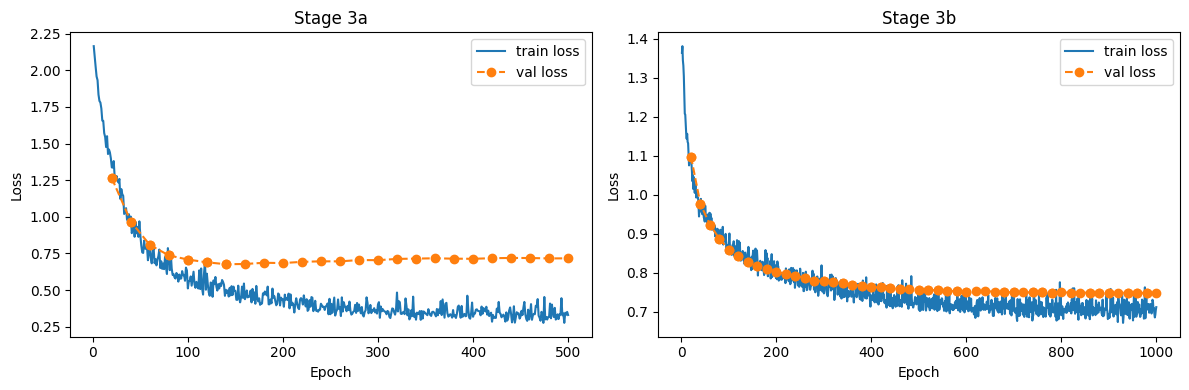

学習曲線を保存: training_curves.png


In [61]:
import re
import matplotlib.pyplot as plt

def parse_log(log_path: str) -> dict:
    """train.log から loss 系列を抽出する。"""
    epochs, losses, val_losses = [], [], []
    ep_pat   = re.compile(r'Epoch\s+(\d+)/\d+.*loss=([\d.]+)')
    val_pat  = re.compile(r'val_loss=([\d.]+)')
    with open(log_path, 'r', encoding='utf-8') as f:
        for line in f:
            m = ep_pat.search(line)
            if m:
                epochs.append(int(m.group(1)))
                losses.append(float(m.group(2)))
            m2 = val_pat.search(line)
            if m2:
                val_losses.append((epochs[-1] if epochs else 0, float(m2.group(1))))
    return {'epochs': epochs, 'losses': losses, 'val': val_losses}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (label, out_dir) in zip(axes, [('Stage 3a', OUT_3A), ('Stage 3b', OUT_3B)]):
    log_path = os.path.join(out_dir, 'train.log')
    if not os.path.exists(log_path):
        ax.set_title(f'{label} (ログなし)')
        continue
    d = parse_log(log_path)
    ax.plot(d['epochs'], d['losses'], label='train loss')
    if d['val']:
        ve, vl = zip(*d['val'])
        ax.plot(ve, vl, 'o--', label='val loss')
    ax.set_title(label)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(PHASE3_DIR, 'training_curves.png'), dpi=120)
plt.show()
print('学習曲線を保存: training_curves.png')

## Step 12 — パッチ‑テキスト類似度の意味的検証

学習済み Stage 3b モデルを使って、歯科解剖クエリに対するパッチの類似度ヒートマップを確認する。

In [62]:
import torch, torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from argparse import Namespace

from phase3_models.stage3_model import build_stage3_models
from phase3_models.text_cache import build_clip_and_cache
from phase3_datasets.dental_dataset import _load_ply, _normalize_unit_sphere, _fps_cpu

# Step 7 でロードしたチェックポイント (Stage 3b best) を使う
cfg_eval = Namespace(
    trans_dim=384, depth=12, drop_path_rate=0.1, cls_dim=50,
    num_heads=6, group_size=32, num_group=128, encoder_dims=256,
    color=False, num_classes=16, clip_dim=1280, clip_tau=0.07,
)
from easydict import EasyDict
cfg_model = EasyDict(vars(cfg_eval))

student, _, proj, _ = build_stage3_models(
    cfg      = cfg_model,
    device   = torch.device(device),
    ckpt_path = '',           # 重みは後でロード
)

eval_ckpt = torch.load(stage3b_best, map_location='cpu', weights_only=False)
student.load_state_dict(eval_ckpt['student'], strict=False)
proj.load_state_dict(eval_ckpt['proj'], strict=False)
student.eval().to(device)
proj.eval().to(device)
print('Stage 3b モデルロード OK')

[Stage3] Student: 学習可能 1,873,536 / 総 21,858,816 パラメータ  Proj: 492,800
Stage 3b モデルロード OK


/tmp/ipykernel_49928/777973860.py:53: UserWarning: Glyph 12497 (\N{KATAKANA LETTER PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_49928/777973860.py:53: UserWarning: Glyph 12483 (\N{KATAKANA LETTER SMALL TU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_49928/777973860.py:53: UserWarning: Glyph 12481 (\N{KATAKANA LETTER TI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_49928/777973860.py:53: UserWarning: Glyph 12486 (\N{KATAKANA LETTER TE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_49928/777973860.py:53: UserWarning: Glyph 12461 (\N{KATAKANA LETTER KI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_49928/777973860.py:53: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_49928/777973860.py:53: UserWarning: Glyph 12488 (\N{KATAKANA LETTER TO}) missing from font(s) DejaVu Sans.
  plt.tight_la

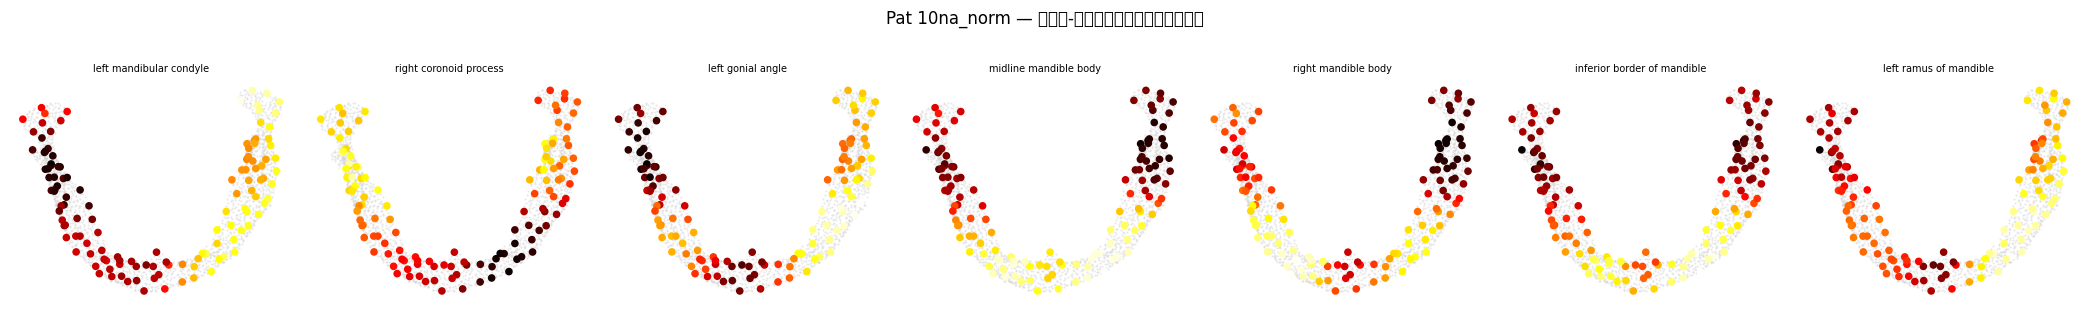

ヒートマップ保存: patch_text_heatmap.png


In [63]:
# 代表 1 症例 (Pat 1a_norm) でクエリ検索
import open_clip

pat_id   = list(candidates.keys())[0]   # 先頭患者
ply_path = Path(PLY_DIR) / f'{pat_id}.ply'

xyz_raw = _load_ply(ply_path)
fps_idx = _fps_cpu(xyz_raw, 2048, seed=42)
xyz     = xyz_raw[fps_idx]
xyz_n, _, _ = _normalize_unit_sphere(xyz)
pts_t   = xyz_n.T.unsqueeze(0).to(device)  # (1, 3, 2048)

# テキストクエリ
text_queries = [
    'left mandibular condyle',
    'right coronoid process',
    'left gonial angle',
    'midline mandible body',
    'right mandible body',
    'inferior border of mandible',
    'left ramus of mandible',
]

clip_m, _, _ = open_clip.create_model_and_transforms(
    'ViT-bigG-14', pretrained='laion2b_s39b_b160k', device=device
)
clip_m.eval()
tok = open_clip.get_tokenizer('ViT-bigG-14')

with torch.no_grad():
    text_feats = F.normalize(
        clip_m.encode_text(tok(text_queries).to(device)), dim=-1
    )  # (T, 1280)

    patch_emb, patch_centers, _ = student.forward_patches(pts_t)
    patch_feat = proj(patch_emb)   # (1, G, 1280)

sim = (patch_feat[0] @ text_feats.T).cpu().numpy()   # (G, T)
centers = patch_centers[0].T.cpu().numpy()           # (G, 3)

# 可視化
fig, axes = plt.subplots(1, len(text_queries), figsize=(3 * len(text_queries), 3))
xyz_np = xyz_n.cpu().numpy()

for i, (ax, q) in enumerate(zip(axes, text_queries)):
    sc = ax.scatter(xyz_np[:, 0], xyz_np[:, 2], c='lightgray', s=0.3, alpha=0.5)
    ax.scatter(centers[:, 0], centers[:, 2],
               c=sim[:, i], cmap='hot', s=20, vmin=sim[:, i].min(), vmax=sim[:, i].max())
    ax.set_title(q, fontsize=7)
    ax.axis('off')

plt.suptitle(f'{pat_id} — パッチ‑テキスト類似度ヒートマップ', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PHASE3_DIR, 'patch_text_heatmap.png'), dpi=120, bbox_inches='tight')
plt.show()
print('ヒートマップ保存: patch_text_heatmap.png')

In [64]:
# ===== Step 12 追加: z軸回転 GIF 生成 =====
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
import imageio.v2 as imageio
import io, os

# imageio がなければインストール
try:
    import imageio.v2
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'imageio', '-q'])
    import imageio.v2 as imageio


def rotate_z(xyz: np.ndarray, theta_deg: float) -> np.ndarray:
    """点群を z 軸周りに theta_deg 度回転 (右手系)"""
    theta = np.radians(theta_deg)
    c, s = np.cos(theta), np.sin(theta)
    R = np.array([[c, -s, 0],
                  [s,  c, 0],
                  [0,  0, 1]], dtype=np.float32)
    return xyz @ R.T


# ----- 設定 -----
DEGREES_PER_FRAME = 10                        # 1フレームあたりの回転角
N_FRAMES          = 360 // DEGREES_PER_FRAME  # 36フレーム
FPS               = 8                         # GIF フレームレート
GIF_DIR           = PHASE3_DIR                # 保存先

os.makedirs(GIF_DIR, exist_ok=True)

# xyz_np, centers, sim, text_queries は Step 12 で定義済みの変数を使用
# xyz_np  : (N, 3)  正規化済み点群
# centers : (G, 3)  パッチ中心
# sim     : (G, T)  コサイン類似度
# text_queries : list[str]

print(f'GIF 生成開始: {len(text_queries)} クエリ × {N_FRAMES} フレーム')

for qi, query in enumerate(text_queries):
    sim_q = sim[:, qi]                        # (G,) このクエリの類似度スコア
    vmin, vmax = float(sim_q.min()), float(sim_q.max())

    frames = []
    for angle in range(0, 360, DEGREES_PER_FRAME):
        xyz_rot     = rotate_z(xyz_np, angle)   # (N, 3)
        centers_rot = rotate_z(centers, angle)  # (G, 3)

        fig, ax = plt.subplots(figsize=(4, 4), facecolor='white')

        # 背景点群 (グレー)
        ax.scatter(xyz_rot[:, 0], xyz_rot[:, 2],
                   c='lightgray', s=0.5, alpha=0.4, linewidths=0)

        # パッチ中心 (類似度ヒートマップ)
        sc = ax.scatter(centers_rot[:, 0], centers_rot[:, 2],
                        c=sim_q, cmap='hot', s=25,
                        vmin=vmin, vmax=vmax, linewidths=0)

        plt.colorbar(sc, ax=ax, fraction=0.04, pad=0.02)
        ax.set_title(f'{query}\n{angle:3d}°', fontsize=7, pad=3)
        ax.set_xlim(-1.2, 1.2)
        ax.set_ylim(-1.2, 1.2)
        ax.set_aspect('equal')
        ax.axis('off')
        plt.tight_layout(pad=0.5)

        # フレームをメモリ上の PNG としてキャプチャ
        buf = io.BytesIO()
        plt.savefig(buf, format='png', dpi=90, bbox_inches='tight')
        buf.seek(0)
        frames.append(imageio.imread(buf))
        plt.close(fig)

    # 全フレームをフレームサイズ統一 (念のため)
    h = min(f.shape[0] for f in frames)
    w = min(f.shape[1] for f in frames)
    frames = [f[:h, :w] for f in frames]

    # GIF 保存
    safe_name = query.replace(' ', '_').replace('/', '-')[:40]
    gif_path  = os.path.join(GIF_DIR, f'heatmap_{qi:02d}_{safe_name}.gif')
    imageio.mimsave(gif_path, frames, fps=FPS, loop=0)
    print(f'  [{qi+1}/{len(text_queries)}] 保存: {gif_path}')

print(f'\n完了。{len(text_queries)} 件の GIF を {GIF_DIR} に保存しました。')


GIF 生成開始: 7 クエリ × 36 フレーム


/tmp/ipykernel_49928/1952823969.py:76: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  frames.append(imageio.imread(buf))


  [1/7] 保存: /content/drive/MyDrive/2026研究/ULIP_PointLLM/DentalPatchAligned3D/Phase3_Training/heatmap_00_left_mandibular_condyle.gif
  [2/7] 保存: /content/drive/MyDrive/2026研究/ULIP_PointLLM/DentalPatchAligned3D/Phase3_Training/heatmap_01_right_coronoid_process.gif
  [3/7] 保存: /content/drive/MyDrive/2026研究/ULIP_PointLLM/DentalPatchAligned3D/Phase3_Training/heatmap_02_left_gonial_angle.gif
  [4/7] 保存: /content/drive/MyDrive/2026研究/ULIP_PointLLM/DentalPatchAligned3D/Phase3_Training/heatmap_03_midline_mandible_body.gif
  [5/7] 保存: /content/drive/MyDrive/2026研究/ULIP_PointLLM/DentalPatchAligned3D/Phase3_Training/heatmap_04_right_mandible_body.gif
  [6/7] 保存: /content/drive/MyDrive/2026研究/ULIP_PointLLM/DentalPatchAligned3D/Phase3_Training/heatmap_05_inferior_border_of_mandible.gif
  [7/7] 保存: /content/drive/MyDrive/2026研究/ULIP_PointLLM/DentalPatchAligned3D/Phase3_Training/heatmap_06_left_ramus_of_mandible.gif

完了。7 件の GIF を /content/drive/MyDrive/2026研究/ULIP_PointLLM/DentalPatchAligned3D/Phase3

## Step 13 — 結果確認 & Phase 4 への引き渡し

| チェック項目 | 期待値 |
|------------|-------|
| Stage 3a best val_loss | 学習が進むにつれ低下していること |
| Stage 3b best val_loss | Stage 3a より低いか同程度 |
| ヒートマップ | 解剖クエリが対応する部位と高い類似度 |
| `stage3b_best.pt` | Drive に保存済み |

In [65]:
import os

PASS = True
checks = [
    ('stage3a_last.pt', stage3a_last),
    ('stage3a best.pt', stage3a_best),
    ('stage3b best.pt', stage3b_best),
    ('stage3b_best.pt (Phase4用)', stage3b_final),
    ('training_curves.png', os.path.join(PHASE3_DIR, 'training_curves.png')),
    ('patch_text_heatmap.png', os.path.join(PHASE3_DIR, 'patch_text_heatmap.png')),
]

for name, path in checks:
    ok = os.path.exists(path)
    PASS = PASS and ok
    status = '[OK]' if ok else '[NG]'
    print(f'{status} {name}')
    if ok:
        size_mb = os.path.getsize(path) / 1e6
        print(f'     → {path}  ({size_mb:.1f} MB)')
    else:
        print(f'     → 見つかりません: {path}')

print()
if PASS:
    print('[PASS] Phase 3 完了 → Phase 4 (Attribution) へ進めます')
    print(f'Phase 4 入力チェックポイント: {stage3b_final}')
else:
    print('[FAIL] 一部のファイルが見つかりません。上のセルを再実行してください。')

[OK] stage3a_last.pt
     → /content/drive/MyDrive/2026研究/ULIP_PointLLM/DentalPatchAligned3D/Phase3_Training/outputs/stage3a/stage3a_last.pt  (89.5 MB)
[OK] stage3a best.pt
     → /content/drive/MyDrive/2026研究/ULIP_PointLLM/DentalPatchAligned3D/Phase3_Training/outputs/stage3a/checkpoints/best.pt  (108.4 MB)
[OK] stage3b best.pt
     → /content/drive/MyDrive/2026研究/ULIP_PointLLM/DentalPatchAligned3D/Phase3_Training/outputs/stage3b/checkpoints/best.pt  (108.4 MB)
[OK] stage3b_best.pt (Phase4用)
     → /content/drive/MyDrive/2026研究/ULIP_PointLLM/DentalPatchAligned3D/Phase3_Training/outputs/stage3b/stage3b_best.pt  (108.4 MB)
[OK] training_curves.png
     → /content/drive/MyDrive/2026研究/ULIP_PointLLM/DentalPatchAligned3D/Phase3_Training/training_curves.png  (0.1 MB)
[OK] patch_text_heatmap.png
     → /content/drive/MyDrive/2026研究/ULIP_PointLLM/DentalPatchAligned3D/Phase3_Training/patch_text_heatmap.png  (0.2 MB)

[PASS] Phase 3 完了 → Phase 4 (Attribution) へ進めます
Phase 4 入力チェックポイント: /content/d

## トラブルシューティング

| 症状 | 原因 | 対処 |
|------|------|------|
| `RuntimeError: 有効な PLY が見つかりません` | PLY_DIR パスまたはファイル名の不一致 | `PLY_DIR` の内容を確認し、ファイルが `Pat Xa_norm.ply` 形式か確認 |
| `assert len(matched) > 0` 失敗 | JSON キーと PLY ファイル名の対応がない | candidates.json のキー名と normPLYs のファイル名 (拡張子除く) が一致するか確認 |
| `CUDA out of memory` | VRAM 不足 | `batch_size` を 2 に下げる。または VRAM 15GB 以上の GPU を使用 |
| `ModuleNotFoundError: patchalign3d` | Step 4 のパス設定が通っていない | Step 4 のセルを再実行し、`_reference_repos/PatchAlign3D/src` が存在するか確認 |
| `strict=False` でキー不一致警告 | HF チェックポイントの形式差異 | 警告のみなら学習継続可能。必要なら `ckpt.keys()` を確認 |
| Stage 3a val_loss が下がらない | 学習率・バッチサイズの調整 | `lr` を `5e-5` に下げる、または `batch_size` を 2 に変更して `lambda_kd` を 0.1 に |
| EWC Fisher 計算が遅い | Fisher バッチ数が多い | `ewc_fisher_batches` を 20 に減らす |
| open_clip download timeout | ネットワーク問題 | セルを再実行 (キャッシュから再開される) |